# Predicción de Precios de Acciones con RNN usando PyTorch

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# DESCARGAMOS DATASET

In [2]:
data = yf.download('KO','2026-01-01','2026-05-30')
data

/tmp/ipykernel_650/2667958898.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('KO','2026-01-01','2026-05-30')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,KO,KO,KO,KO,KO
Date,,,,,
2026-01-02,68.647980,69.392858,68.508936,69.372990,12151300
2026-01-05,67.476036,68.449339,67.456168,68.449339,21186600
2026-01-06,67.376717,67.783920,67.128424,67.545561,21019900
2026-01-07,67.078766,67.605145,66.810605,67.525690,20223400
2026-01-08,68.896271,68.985652,66.989377,67.078766,19237000
...,...,...,...,...,...
2026-05-20,81.550003,82.400002,81.519997,82.169998,16999700
2026-05-21,81.169998,81.800003,80.720001,81.790001,15708400


In [3]:
# Renombrar las columnas eliminando el MultiIndex y aplicando snake_case
data.columns = [f"{col[0].lower()}_{col[1].lower()}" for col in data.columns]

# Mostrar las nuevas columnas
print(data.head())

             close_ko    high_ko     low_ko    open_ko  volume_ko
Date                                                             
2026-01-02  68.647980  69.392858  68.508936  69.372990   12151300
2026-01-05  67.476036  68.449339  67.456168  68.449339   21186600
2026-01-06  67.376717  67.783920  67.128424  67.545561   21019900
2026-01-07  67.078766  67.605145  66.810605  67.525690   20223400
2026-01-08  68.896271  68.985652  66.989377  67.078766   19237000


In [4]:
df = data[['close_ko']]
df = df.rename(columns={'close_ko': 'close'})

In [5]:
df

,close
Date,
2026-01-02,68.647980
2026-01-05,67.476036
2026-01-06,67.376717
2026-01-07,67.078766
2026-01-08,68.896271
...,...
2026-05-20,81.550003
2026-05-21,81.169998
2026-05-22,81.480003


In [7]:
data = df.copy()
data

,close
Date,
2026-01-02,68.647980
2026-01-05,67.476036
2026-01-06,67.376717
2026-01-07,67.078766
2026-01-08,68.896271
...,...
2026-05-20,81.550003
2026-05-21,81.169998
2026-05-22,81.480003


# NORMALIZAR Y CREAR SECUENCIAS

In [6]:
def normalize_data(data):
    """
    Normaliza los datos entre 0 y 1.
    """
    return (data - np.min(data)) / (np.max(data) - np.min(data))

def create_sequences(data, sequence_length):
    """
    Crea secuencias de datos para la RNN con una longitud específica.
    """
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

In [8]:
# Preprocesamiento de los datos
close_data = data['close'].values.reshape(-1, 1)
print("Primeros 5 valores de close_data:")
print(close_data[:5])

scaled_data = normalize_data(close_data)
print("\nPrimeros 5 valores de scaled_data (normalizados):")
print(scaled_data[:5])

sequence_length = 60
X, y = create_sequences(scaled_data, sequence_length)
print("\nForma de X e Y después de crear secuencias:")
print("X:", X.shape)
print("y:", y.shape)

# Convertir a tensores de PyTorch
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
print("\nTamaño de X después de convertir a tensores:")
print(X.size())
print("Tamaño de y después de convertir a tensores:")
print(y.size())

# Dividir los datos en conjuntos de entrenamiento y prueba
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

print("\nTamaño de X_train:", X_train.size())
print("Tamaño de y_train:", y_train.size())
print("Tamaño de X_test:", X_test.size())
print("Tamaño de y_test:", y_test.size())

Primeros 5 valores de close_data:
[[68.64797974]
 [67.47603607]
 [67.37671661]
 [67.07876587]
 [68.89627075]]

Primeros 5 valores de scaled_data (normalizados):
[[0.10573339]
 [0.02676801]
 [0.02007588]
 [0.        ]
 [0.12246321]]

Forma de X e Y después de crear secuencias:
X: (40, 60, 1)
y: (40, 1)

Tamaño de X después de convertir a tensores:
torch.Size([40, 60, 1])
Tamaño de y después de convertir a tensores:
torch.Size([40, 1])

Tamaño de X_train: torch.Size([32, 60, 1])
Tamaño de y_train: torch.Size([32, 1])
Tamaño de X_test: torch.Size([8, 60, 1])
Tamaño de y_test: torch.Size([8, 1])


# CREAMOS NUESTRO MODELO DE RNN CON LSTM CON PYTORCH

In [9]:
class StockPredictor(nn.Module):
  def __init__(self,input_size=1,hidden_layer_size=50,output_size=1):
    super(StockPredictor, self).__init__()
    self.hidden_layer_size = hidden_layer_size
    self.rnn = nn.RNN(input_size, hidden_layer_size, batch_first=True)
    self.linear = nn.Linear(hidden_layer_size, output_size)

  def forward(self, input_seq, hidden_cell):
    rnn_out, hidden_cell = self.rnn(input_seq, hidden_cell)
    predictions = self.linear(rnn_out[:, -1])
    return predictions, hidden_cell

  def init_hidden(self,batch_size):
    return torch.zeros(1,batch_size,self.hidden_layer_size)

In [10]:
model = StockPredictor()
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

# ENTRENAMOS NUESTRO MODELO

In [11]:

def train_model(model, X_train, y_train, epochs=25):
    """
    Entrena el modelo de RNN con los datos de entrenamiento.
    """
    for epoch in range(epochs):
      for idx in range(len(X_train)):
        seq = X_train[idx]
        label = X_train[idx]

        optimizer.zero_grad()

        # Inicializar el estado oculto para cada secuencia
        hidden_cell = model.init_hidden(1)

        y_pred, hidden_cell = model(seq.unsqueeze(0), hidden_cell)
        single_loss = loss_function(y_pred, label.unsqueeze(0))
        single_loss.backward()
        optimizer.step()
      print(f'Epoch {epoch}, Loss : {single_loss.item()}')

In [12]:
train_model(model, X_train, y_train, epochs=1000)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1, 60, 1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 0, Loss : 0.015445685014128685
Epoch 1, Loss : 0.016653232276439667
Epoch 2, Loss : 0.01584961637854576
Epoch 3, Loss : 0.015332953073084354
Epoch 4, Loss : 0.014957425184547901
Epoch 5, Loss : 0.014725317247211933
Epoch 6, Loss : 0.014612389728426933
Epoch 7, Loss : 0.014584943652153015
Epoch 8, Loss : 0.0146175567060709
Epoch 9, Loss : 0.014693065546452999
Epoch 10, Loss : 0.014798665419220924
Epoch 11, Loss : 0.014922876842319965
Epoch 12, Loss : 0.01505401823669672
Epoch 13, Loss : 0.015179803594946861
Epoch 14, Loss : 0.015288114547729492
Epoch 15, Loss : 0.01536835078150034
Epoch 16, Loss : 0.015413021668791771
Epoch 17, Loss : 0.015418874099850655
Epoch 18, Loss : 0.01538714487105608
Epoch 19, Loss : 0.015322855673730373
Epoch 20, Loss : 0.015233333222568035
Epoch 21, Loss : 0.015126679092645645
Epoch 22, Loss : 0.015010476112365723
Epoch 23, Loss : 0.014891046099364758
Epoch 24, Loss : 0.014773165807127953
Epoch 25, Loss : 0.014660217799246311
Epoch 26, Loss : 0.014554397

# EVALUAMOS EL MODELO

In [14]:
def evaluate_model(model, X_test, y_test):
    """
    Evalúa el modelo y realiza predicciones sobre los datos de prueba.
    """
    model.eval()
    predictions = []
    for seq in X_test:
        with torch.no_grad():
            hidden_cell = model.init_hidden(1)

            y_pred, hidden_cell = model(seq.unsqueeze(0), hidden_cell)
            predictions.append(y_pred.item())

    predictions = np.array(predictions).reshape(-1, 1)
    predictions = predictions * (np.max(close_data) - np.min(close_data)) + np.min(close_data)

    # Calcular el RMSE
    rmse = np.sqrt(np.mean((predictions - (y_test.numpy() * (np.max(close_data) - np.min(close_data)) + np.min(close_data)))**2))
    print(f'Root Mean Squared Error: {rmse}')

    return predictions

In [15]:
predictions = evaluate_model(model, X_test, y_test)

Root Mean Squared Error: 3.427416157648278


# VISUALIZAMOS RESULTADOS

/tmp/ipykernel_650/3780485977.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


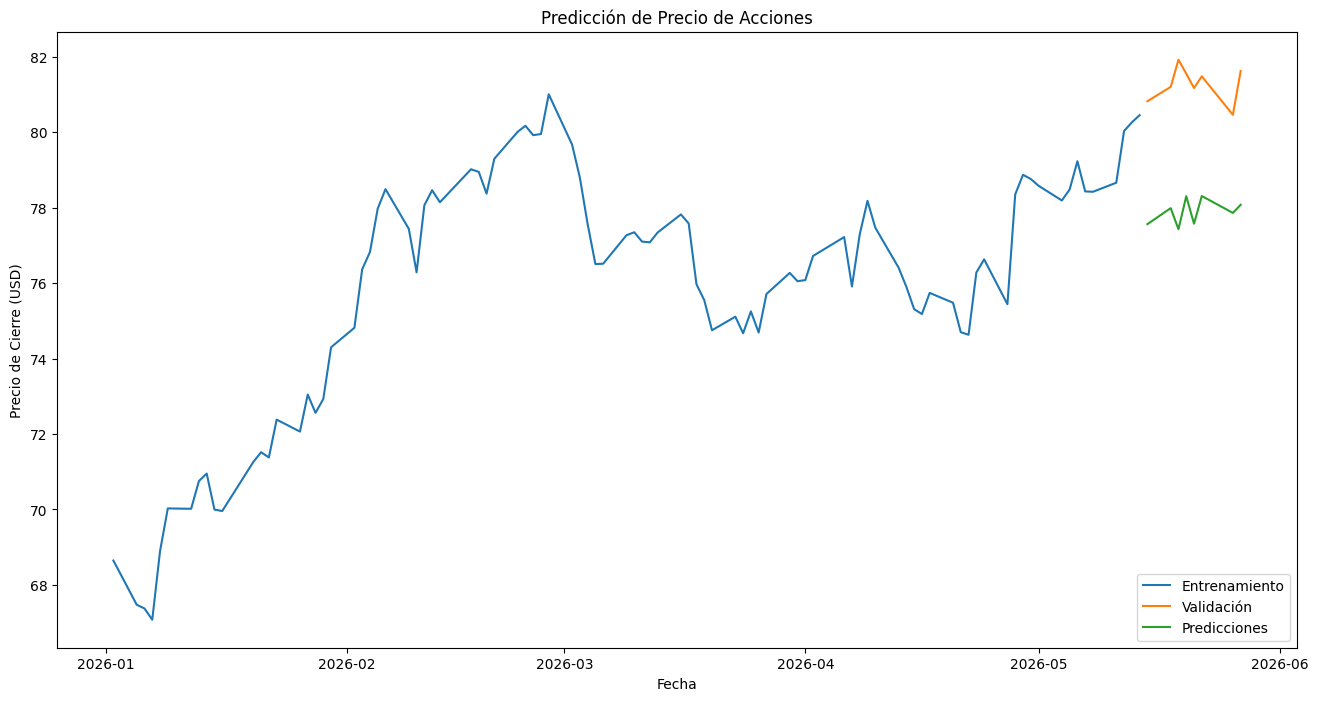

                close  Predictions
Date                              
2026-05-20  81.550003    78.303796
2026-05-21  81.169998    77.574440
2026-05-22  81.480003    78.308267
2026-05-26  80.459999    77.860111
2026-05-27  81.620003    78.075557


In [16]:
def plot_results(data, train_size, predictions):
    """
    Visualiza los resultados de las predicciones frente a los valores reales.
    """
    train = data[:train_size + sequence_length]
    valid = data[train_size + sequence_length:]
    valid['Predictions'] = predictions

    plt.figure(figsize=(16, 8))
    plt.title('Predicción de Precio de Acciones')
    plt.xlabel('Fecha')
    plt.ylabel('Precio de Cierre (USD)')
    plt.plot(train['close'])
    plt.plot(valid[['close', 'Predictions']])
    plt.legend(['Entrenamiento', 'Validación', 'Predicciones'], loc='lower right')
    plt.show()

    print(valid[['close', 'Predictions']].tail())

# Visualización de los resultados
plot_results(data, train_size, predictions)